# 🏋️ Tema 4: Preparación y Preprocesamiento de Datos

## *Estrategia del Dato: Machine Learning y Deep Learning*

---

### 👨‍🏫 Sesión Práctica
**Objetivo:** Transformar los conceptos teóricos de recolección, limpieza, tratamiento de nulos, detección de outliers y normalización en código ejecutable con **Python, Pandas, Matplotlib y Seaborn**.

### 📋 Contenido del Cuaderno
1. **Introducción a Google Colab:** Entorno, kernels y celdas.
2. **Preparación del Entorno:** Importación de librerías esenciales.
3. **Gestión de Datos:** Carga de CSV y estructuras (DataFrames/Series).
4. **Exploración y Limpieza:** Análisis inicial, duplicados e inconsistencias.
5. **Tratamiento de Datos Faltantes:** Identificación e imputación.
6. **Análisis de Outliers:** Detección estadística y corrección.
7. **EDA Visual:** Histogramas, correlaciones y relaciones.
8. **Escalado de Datos:** Normalización y Estandarización.
9. **Pipeline Final:** Automatización del proceso de limpieza.

---

**📦 Dataset:** `gimnasio_gympro.csv` (Datos sintéticos de socios con nulos, outliers e inconsistencias).

## 1. 🚀 Introducción a Google Colab

**Google Colab** es un entorno de cuadernos en la nube que permite ejecutar Python sin configuración local, facilitando la colaboración y el acceso a recursos de cómputo (CPU/GPU).

### 🔑 Conceptos Esenciales

*   **Notebook (`.ipynb`):** Documento interactivo que mezcla celdas de **Texto** (Markdown) y **Código** (Python).
*   **Celdas de Código:** Bloques ejecutables (usa `Shift + Enter` o el botón ▶️).
*   **Kernel:** Motor de ejecución que mantiene las variables en memoria. *Si se reinicia, se pierden los datos temporales.*
*   **Runtime:** El servidor remoto donde se procesa tu código.

### 📥 Primeros Pasos
1. **Carga el Notebook:** Sube este archivo `.ipynb` a Colab.
2. **Sube el Dataset:** Haz clic en el icono de carpeta (📁) a la izquierda y arrastra `gimnasio_gympro.csv`.
3. **Orden de Ejecución:** Es vital ejecutar las celdas secuencialmente para mantener la integridad de las variables.

> 💡 **Tip:** Puedes consultar la ayuda de cualquier función de Pandas añadiendo un signo de interrogación, por ejemplo: `pd.read_csv?`

---

## 2. 📚 Preparación: Importación de Librerías

Antes de procesar cualquier dato, debemos cargar nuestro kit de herramientas. Utilizaremos las **cuatro librerías fundamentales** del ecosistema de ciencia de datos en Python:

| Librería | Propósito principal | Alias común |
| :--- | :--- | :--- |
| **Pandas** | Manipulación de tablas (DataFrames) y limpieza. | `pd` |
| **NumPy** | Operaciones matemáticas y manejo de arrays. | `np` |
| **Matplotlib** | Visualización de datos básica. | `plt` |
| **Seaborn** | Gráficos estadísticos avanzados y estéticos. | `sns` |

> 💡 **Convención de alias:** Usamos `as` para crear alias cortos. Es un estándar en la industria que facilita la lectura y escritura del código.

In [2]:
# Importamos las librerías esenciales
import pandas as pd                  # manipulación de DataFrames
import numpy as np                   # cálculo numérico
import matplotlib.pyplot as plt      # gráficos básicos
import seaborn as sns                # gráficos estadísticos

# Configuramos el estilo visual de los gráficos
sns.set_theme(style="whitegrid", palette="pastel")
plt.rcParams["figure.figsize"] = (10, 5)   # tamaño por defecto de las figuras

# Mostramos las versiones para verificar que está todo instalado
print("Pandas:    ", pd.__version__)
print("NumPy:     ", np.__version__)
print("Seaborn:   ", sns.__version__)
print("\n✅ ¡Librerías cargadas correctamente!")

Pandas:     2.2.2
NumPy:      2.0.2
Seaborn:    0.13.2

✅ ¡Librerías cargadas correctamente!


---

## 3. 🧱 Estructuras Fundamentales: DataFrame vs. Serie

Para dominar Pandas, es vital distinguir entre sus dos objetos principales:

### 📊 1. DataFrame
*   Es una **tabla bidimensional** (filas y columnas).
*   Similar a una hoja de cálculo de Excel o una tabla SQL.
*   Cada columna puede contener un tipo de dato diferente (int, float, string).

### 📏 2. Serie (`Series`)
*   Es una **única columna** de datos.
*   Es unidimensional y posee un índice.
*   Un DataFrame es, técnicamente, una colección de Series que comparten el mismo índice.

---

In [3]:
# Crear una Serie a partir de una lista
edades = pd.Series([25, 30, 22, 45, 28], name="Edad")
print("📏 Serie:")
print(edades)
print("\nTipo:", type(edades).__name__)

📏 Serie:
0    25
1    30
2    22
3    45
4    28
Name: Edad, dtype: int64

Tipo: Series


In [4]:
# Crear un DataFrame a partir de un diccionario
data = {
    "Nombre": ["Alice", "Bob", "Charlie", "Diana"],
    "Edad":   [25, 30, 22, 45],
    "Ciudad": ["Madrid", "Barcelona", "Valencia", "Sevilla"]
}
df_ejemplo = pd.DataFrame(data)
print("📊 DataFrame:")
df_ejemplo

📊 DataFrame:


,Nombre,Edad,Ciudad
0,Alice,25,Madrid
1,Bob,30,Barcelona
2,Charlie,22,Valencia
3,Diana,45,Sevilla


¿Ves la diferencia? El DataFrame tiene varias columnas con distintos tipos, mientras que la Serie es una sola columna.> 💡 **En la práctica el 99% del tiempo trabajaremos con DataFrames.** Cuando seleccionamos una sola columna de un DataFrame (`df["Edad"]`), Pandas nos devuelve una Serie.

---

## 4. 📂 Ingesta de Datos: Carga de CSV

El formato CSV (*Comma Separated Values*) es el estándar para el intercambio de datos. En Colab, tenemos un flujo de trabajo específico:

### 🛠️ Flujo de Trabajo en la Nube
1.  **Carga Temporal:** Sube el archivo `gimnasio_gympro.csv` usando el panel lateral de archivos (📁).
2.  **Lectura con Pandas:** Utilizamos el método `pd.read_csv()`.
3.  **Persistencia:** Recuerda que los archivos subidos manualmente se eliminan al finalizar la sesión.

> 🔍 **Nota Técnica:** `read_csv` es extremadamente potente y permite configurar delimitadores, tipos de codificación (encoding) y manejo de fechas desde el momento de la carga.

In [7]:
# Leemos el CSV y lo guardamos en una variable llamada 'df'
# (df = "DataFrame", es una convención muy extendida)
df = pd.read_csv("gimnasio_gympro.csv")

# Ver el tipo de objeto que hemos creado
print("Tipo:", type(df).__name__)
print("Tamaño:", df.shape, "  (filas, columnas)")


Tipo: DataFrame
Tamaño: (308, 15)   (filas, columnas)


> 🔍 **¿Qué significa `df.shape`?** Devuelve una tupla `(nº filas, nº columnas)`. Es la primera comprobación que se hace siempre al cargar un dataset.### 🌐 Alternativa: leer un CSV desde una URL`read_csv()` también admite URLs. Por ejemplo:```pythonurl = "https://raw.githubusercontent.com/.../mi_dataset.csv"df = pd.read_csv(url)```

---

## 5. 🔎 Inspección y Exploración Inicial

Una vez cargados los datos, el primer paso es la **auditoría visual**. No podemos limpiar lo que no comprendemos. Estas son las funciones esenciales de inspección:

### 🛠️ Caja de Herramientas de Exploración

*   `df.head()` / `df.tail()`: Inspección de los extremos del dataset.
*   `df.info()`: Diagnóstico de tipos de datos y conteo de valores nulos.
*   `df.describe()`: Resumen estadístico (tendencia central y dispersión).
*   `df.shape`: Dimensiones exactas (filas, columnas).

---

In [ ]:
# Las primeras 5 filas
df.head()

,ID_Socio,Nombre,Genero,Edad,Altura_cm,Peso_kg,Ciudad,Plan,Cuota_mensual_EUR,Antiguedad_meses,Dias_por_semana,Minutos_por_sesion,Calorias_quemadas,Satisfaccion,Fecha_inscripcion
0,1001,María Molina,F,41.0,NaN,86.4,Madrid,Estándar,29.99,103,7,51.0,465.0,7.0,2025-08-18
1,1002,Daniel González,femenino,33.0,164.4,NaN,Granada,Premium,49.99,68,1,42.0,300.0,3.0,2024-07-18
2,1003,Claudia López,F,43.0,177.5,88.0,Madrid,Básico,49.99,115,7,57.0,518.0,6.0,2021-04-25
3,1004,Lucía García,F,53.0,176.1,95.3,Barcelona,Básico,39.99,1,3,94.0,949.0,NaN,2025-02-26
4,1005,Daniel Navarro,M,32.0,169.8,81.2,Madrid,Básico,29.99,92,6,NaN,212.0,9.0,2020-07-04


In [ ]:
# Las primeras 10 filas
df.head(10)

,ID_Socio,Nombre,Genero,Edad,Altura_cm,Peso_kg,Ciudad,Plan,Cuota_mensual_EUR,Antiguedad_meses,Dias_por_semana,Minutos_por_sesion,Calorias_quemadas,Satisfaccion,Fecha_inscripcion
0,1001,María Molina,F,41.0,NaN,86.4,Madrid,Estándar,29.99,103,7,51.0,465.0,7.0,2025-08-18
1,1002,Daniel González,femenino,33.0,164.4,NaN,Granada,Premium,49.99,68,1,42.0,300.0,3.0,2024-07-18
2,1003,Claudia López,F,43.0,177.5,88.0,Madrid,Básico,49.99,115,7,57.0,518.0,6.0,2021-04-25
3,1004,Lucía García,F,53.0,176.1,95.3,Barcelona,Básico,39.99,1,3,94.0,949.0,NaN,2025-02-26
4,1005,Daniel Navarro,M,32.0,169.8,81.2,Madrid,Básico,29.99,92,6,NaN,212.0,9.0,2020-07-04
5,1006,Claudia Rodríguez,F,150.0,171.2,103.2,Zaragoza,Básico,29.99,63,5,28.0,226.0,10.0,2019-11-03
6,1007,Claudia Moreno,F,NaN,182.8,63.4,Sevilla,Estándar,39.99,24,4,89.0,768.0,8.0,2019-04-24
7,1008,Marcos Gómez,M,44.0,164.1,56.3,Zaragoza,Estándar,79.99,99,5,56.0,515.0,5.0,2018-11-12
8,1009,María Pérez,F,29.0,175.5,48.3,Barcelona,Estándar,39.99,13,6,47.0,452.0,5.0,2024-10-07
9,1010,Cristina Gómez,F,42.0,168.0,97.4,Barcelona,Estándar,29.99,111,3,81.0,710.0,5.0,2022-12-26


In [ ]:
# Las últimas 5 filas (útil para ver si hay basura al final)
df.tail()

,ID_Socio,Nombre,Genero,Edad,Altura_cm,Peso_kg,Ciudad,Plan,Cuota_mensual_EUR,Antiguedad_meses,Dias_por_semana,Minutos_por_sesion,Calorias_quemadas,Satisfaccion,Fecha_inscripcion
303,1214,Alejandro Jiménez,M,43.0,160.9,77.9,Sevilla,Básico,39.99,8,3,83.0,NaN,6.0,2019-11-23
304,1107,Beatriz Ruiz,F,58.0,159.3,55.8,Madrid,Básico,49.99,38,4,44.0,NaN,7.0,2022-10-06
305,1128,Laura Fernández,F,28.0,176.9,80.2,Barcelona,Básico,29.99,64,7,100.0,868.0,6.0,2025-12-08
306,1177,Raquel Moreno,F,35.0,175.8,64.1,Bilbao,Estándar,29.99,30,4,48.0,579.0,8.0,2023-08-27
307,1074,Javier Gil,M,54.0,179.6,69.4,Málaga,Estándar,39.99,15,4,83.0,538.0,5.0,2018-01-21


In [ ]:
# Una muestra aleatoria de 5 filas
df.sample(5, random_state=42)

,ID_Socio,Nombre,Genero,Edad,Altura_cm,Peso_kg,Ciudad,Plan,Cuota_mensual_EUR,Antiguedad_meses,Dias_por_semana,Minutos_por_sesion,Calorias_quemadas,Satisfaccion,Fecha_inscripcion
288,1289,Diego Serrano,M,38.0,178.3,83.9,Bilbao,Estándar,59.99,38,1,63.0,762.0,6.0,2023-09-16
9,1010,Cristina Gómez,F,42.0,168.0,97.4,Barcelona,Estándar,29.99,111,3,81.0,710.0,5.0,2022-12-26
57,1058,Álvaro Moreno,M,31.0,167.1,74.6,Barcelona,Premium,29.99,19,6,21.0,243.0,5.0,2022-12-06
60,1061,Beatriz Álvarez,F,29.0,NaN,66.4,Barcelona,Básico,39.99,108,4,56.0,533.0,7.0,2019-03-14
25,1026,Lucía Fernández,F,36.0,157.9,67.3,Barcelona,Estándar,49.99,28,3,63.0,508.0,6.0,2022-04-16


### 🧮 `df.info()` — el método imprescindible`info()` te dice **dos cosas críticas**:1. **Cuántos valores no nulos tiene cada columna** → te chiva qué columnas tienen NaN.2. **El tipo de dato de cada columna** → `int64`, `float64`, `object` (texto), `datetime64`, etc.Si una columna debería ser numérica y aparece como `object`, ¡algo huele mal!

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 308 entries, 0 to 307
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID_Socio            308 non-null    int64  
 1   Nombre              308 non-null    object 
 2   Genero              308 non-null    object 
 3   Edad                293 non-null    float64
 4   Altura_cm           283 non-null    float64
 5   Peso_kg             287 non-null    float64
 6   Ciudad              299 non-null    object 
 7   Plan                308 non-null    object 
 8   Cuota_mensual_EUR   308 non-null    float64
 9   Antiguedad_meses    308 non-null    int64  
 10  Dias_por_semana     308 non-null    int64  
 11  Minutos_por_sesion  290 non-null    float64
 12  Calorias_quemadas   276 non-null    float64
 13  Satisfaccion        296 non-null    float64
 14  Fecha_inscripcion   308 non-null    object 
dtypes: float64(7), int64(3), object(5)
memory usage: 36.2+ KB

### 📊 `df.describe()` — estadística descriptiva en una líneaPor defecto, `describe()` solo muestra **columnas numéricas** y devuelve:- **count** → nº de valores no nulos.- **mean** → media.- **std** → desviación estándar.- **min**, **25%**, **50%** (mediana), **75%**, **max** → mínimo, cuartiles y máximo.Esta tabla es **oro puro** para detectar outliers y valores raros.

In [ ]:
df.describe()

,ID_Socio,Edad,Altura_cm,Peso_kg,Cuota_mensual_EUR,Antiguedad_meses,Dias_por_semana,Minutos_por_sesion,Calorias_quemadas,Satisfaccion
count,308.000000,293.000000,283.000000,287.000000,308.000000,308.000000,308.000000,290.000000,276.000000,296.000000
mean,1150.487013,36.085324,169.651590,76.632056,46.548442,58.064935,3.785714,64.786207,547.532609,6.770270
std,85.922527,17.162685,13.042555,18.373944,56.156829,33.965335,1.488126,37.380525,210.754391,2.052182
min,1001.000000,3.000000,50.000000,25.000000,29.990000,1.000000,1.000000,15.000000,136.000000,1.000000
25%,1076.750000,27.000000,162.350000,66.400000,29.990000,28.750000,3.000000,48.000000,414.250000,6.000000
50%,1150.500000,36.000000,169.800000,75.400000,39.990000,57.000000,4.000000,62.000000,517.500000,7.000000
75%,1223.250000,43.000000,176.450000,86.000000,49.990000,86.000000,5.000000,77.750000,662.250000,8.000000
max,1300.000000,220.000000,250.000000,250.000000,999.990000,119.000000,7.000000,600.000000,2000.000000,10.000000


In [ ]:
# También podemos pedir el describe de las columnas categóricas
df.describe(include="object")

,Nombre,Genero,Ciudad,Plan,Fecha_inscripcion
count,308,308,299,308,308
unique,254,4,12,7,300
top,Andrea Sánchez,M,Madrid,Estándar,2019-09-13
freq,3,154,67,126,2


> 🔥 **Ya estamos viendo problemas:** mira el `max` de la columna `Edad` o `Altura_cm`. ¿Tiene sentido que alguien tenga 220 años o mida 250 cm? **No.** Son outliers que tendremos que tratar más adelante.### 🧱 Acceder a columnas, filas y valores

In [ ]:
# Acceder a una columna (nos devuelve una Serie)
df["Edad"].head()

0    41.0
1    33.0
2    43.0
3    53.0
4    32.0
Name: Edad, dtype: float64

In [ ]:
# Acceder a varias columnas (DataFrame)
df[["Nombre", "Edad", "Plan"]].head()

,Nombre,Edad,Plan
0,María Molina,41.0,Estándar
1,Daniel González,33.0,Premium
2,Claudia López,43.0,Básico
3,Lucía García,53.0,Básico
4,Daniel Navarro,32.0,Básico


In [ ]:
# Acceder a filas por posición usando .iloc
print("Primera fila:")
print(df.iloc[0])

Primera fila:
ID_Socio                      1001
Nombre                María Molina
Genero                           F
Edad                          41.0
Altura_cm                      NaN
Peso_kg                       86.4
Ciudad                      Madrid
Plan                      Estándar
Cuota_mensual_EUR            29.99
Antiguedad_meses               103
Dias_por_semana                  7
Minutos_por_sesion            51.0
Calorias_quemadas            465.0
Satisfaccion                   7.0
Fecha_inscripcion       2025-08-18
Name: 0, dtype: object


In [ ]:
# Acceder a filas por etiqueta usando .loc
# (en este caso el índice coincide con la posición porque no lo hemos cambiado)
df.loc[0:4, ["Nombre", "Edad", "Ciudad"]]

,Nombre,Edad,Ciudad
0,María Molina,41.0,Madrid
1,Daniel González,33.0,Granada
2,Claudia López,43.0,Madrid
3,Lucía García,53.0,Barcelona
4,Daniel Navarro,32.0,Madrid


---

## 6. 👯 Detección y eliminación de duplicados

Los duplicados son filas **exactamente iguales** que aparecen más de una vez. Son una de las primeras cosas que hay que limpiar porque distorsionan los resultados (medias, conteos, modelos…).

### 🧰 Métodos clave

| Método | Descripción |
| :--- | :--- |
| `df.duplicated()` | Serie booleana: `True` si la fila es duplicada. |
| `df.duplicated().sum()` | Cuenta cuántas filas duplicadas hay en total. |
| `df.drop_duplicates()` | Elimina los duplicados (devuelve un nuevo DataFrame). |

In [ ]:
# ¿Cuántos duplicados tenemos?
n_dup = df.duplicated().sum()
print(f"🔁 Filas duplicadas detectadas: {n_dup}")

🔁 Filas duplicadas detectadas: 7


In [ ]:
# Vemos QUÉ filas son duplicadas
df[df.duplicated(keep=False)].sort_values("ID_Socio").head(10)

,ID_Socio,Nombre,Genero,Edad,Altura_cm,Peso_kg,Ciudad,Plan,Cuota_mensual_EUR,Antiguedad_meses,Dias_por_semana,Minutos_por_sesion,Calorias_quemadas,Satisfaccion,Fecha_inscripcion
73,1074,Javier Gil,M,54.0,179.6,69.4,Málaga,Estándar,39.99,15,4,83.0,538.0,5.0,2018-01-21
307,1074,Javier Gil,M,54.0,179.6,69.4,Málaga,Estándar,39.99,15,4,83.0,538.0,5.0,2018-01-21
106,1107,Beatriz Ruiz,F,58.0,159.3,55.8,Madrid,Básico,49.99,38,4,44.0,NaN,7.0,2022-10-06
304,1107,Beatriz Ruiz,F,58.0,159.3,55.8,Madrid,Básico,49.99,38,4,44.0,NaN,7.0,2022-10-06
127,1128,Laura Fernández,F,28.0,176.9,80.2,Barcelona,Básico,29.99,64,7,100.0,868.0,6.0,2025-12-08
305,1128,Laura Fernández,F,28.0,176.9,80.2,Barcelona,Básico,29.99,64,7,100.0,868.0,6.0,2025-12-08
176,1177,Raquel Moreno,F,35.0,175.8,64.1,Bilbao,Estándar,29.99,30,4,48.0,579.0,8.0,2023-08-27
306,1177,Raquel Moreno,F,35.0,175.8,64.1,Bilbao,Estándar,29.99,30,4,48.0,579.0,8.0,2023-08-27
185,1186,David Serrano,M,44.0,155.8,91.2,Madrid,Estándar,29.99,77,5,43.0,438.0,6.0,2020-12-03
302,1186,David Serrano,M,44.0,155.8,91.2,Madrid,Estándar,29.99,77,5,43.0,438.0,6.0,2020-12-03


In [ ]:
# Eliminamos duplicados y reasignamos al mismo DataFrame
df = df.drop_duplicates().reset_index(drop=True)

print("Después de eliminar duplicados:")
print("Forma:", df.shape)
print("Duplicados restantes:", df.duplicated().sum())

Después de eliminar duplicados:
Forma: (301, 15)
Duplicados restantes: 0


> 🧠 **Nota sobre Índices:** `reset_index(drop=True)` reorganiza los índices de las filas para que sean 0, 1, 2, 3… Si no lo hacemos, el índice queda con "huecos" donde estaban los duplicados eliminados.

---

## 7. 🧹 Limpieza de inconsistencias en columnas categóricas

Mira las columnas `Genero` y `Plan`. Si vamos a contar valores únicos, veremos que la misma categoría aparece escrita de varias formas (mayúsculas, espacios, idiomas mezclados…). Esto es **muy típico** en datos reales que vienen de formularios humanos.

In [ ]:
print("Valores únicos en 'Genero':")
print(df["Genero"].unique())

print("\nValores únicos en 'Plan':")
print(df["Plan"].unique())

print("\nValores únicos en 'Ciudad':")
print(df["Ciudad"].dropna().unique())

Valores únicos en 'Genero':
['F' 'femenino' 'M' 'masculino']

Valores únicos en 'Plan':
['Estándar' 'Premium' 'Básico' 'VIP' 'estándar' 'PREMIUM' ' Básico']

Valores únicos en 'Ciudad':
['Madrid' 'Granada' 'Barcelona' 'Zaragoza' 'Sevilla' 'Bilbao' 'Málaga'
 'Valencia' 'málaga' 'barcelona' 'valencia' 'madrid']


### 🛠️ Estandarizar el formato

Vamos a aplicar las siguientes transformaciones:
1. **Quitar espacios** en blanco al principio y al final con `.str.strip()`.
2. **Pasar todo a minúsculas y luego capitalizar** con `.str.lower().str.capitalize()`.
3. **Mapear** los valores antiguos a un formato unificado mediante diccionarios.

In [ ]:
# 1) Limpiar la columna 'Genero': que solo haya "M" o "F"
df["Genero"] = (
    df["Genero"]
    .str.strip()
    .str.lower()
    .map({"m": "M", "f": "F",
          "masculino": "M", "femenino": "F"})
)

print("Géneros tras limpieza:", df["Genero"].unique())

Géneros tras limpieza: ['F' 'M']


In [ ]:
# 2) Limpiar 'Plan': capitalizar y quitar espacios
df["Plan"] = df["Plan"].str.strip().str.capitalize()

# Unificamos los nombres reconocibles (acentos)
df["Plan"] = df["Plan"].replace({
    "Estándar": "Estándar",
    "Premium":  "Premium",
    "Básico":   "Básico",
    "Vip":      "VIP",
})
print("Planes tras limpieza:", df["Plan"].unique())

Planes tras limpieza: ['Estándar' 'Premium' 'Básico' 'VIP']


In [ ]:
# 3) Limpiar 'Ciudad': capitalizar
df["Ciudad"] = df["Ciudad"].str.strip().str.capitalize()
print("Ciudades tras limpieza:", df["Ciudad"].dropna().unique())

Ciudades tras limpieza: ['Madrid' 'Granada' 'Barcelona' 'Zaragoza' 'Sevilla' 'Bilbao' 'Málaga'
 'Valencia']


---

## 8. 🕳️ Manejo de valores nulos (NaN)

Los **valores faltantes** (representados por `NaN` — *Not a Number*) son uno de los problemas más comunes y peligrosos. Si los ignoras, los modelos fallan o producen resultados sesgados.

### 🧰 Detección de nulos

| Método | ¿Qué hace? |
| :--- | :--- |
| `df.isnull()` / `df.isna()` | Devuelve un DataFrame booleano: `True` si el valor es NaN. |
| `df.isnull().sum()` | Cuenta los NaN por columna. |
| `df.isnull().sum().sum()` | Total de NaN en todo el DataFrame. |
| `df.notnull()` | Lo contrario: `True` si NO es NaN. |

In [ ]:
# Conteo de nulos por columna
print("🕳️ Valores nulos por columna:")
print(df.isnull().sum().sort_values(ascending=False))

🕳️ Valores nulos por columna:
Calorias_quemadas     30
Altura_cm             25
Peso_kg               21
Minutos_por_sesion    18
Edad                  15
Satisfaccion          12
Ciudad                 9
ID_Socio               0
Nombre                 0
Genero                 0
Plan                   0
Cuota_mensual_EUR      0
Antiguedad_meses       0
Dias_por_semana        0
Fecha_inscripcion      0
dtype: int64


In [ ]:
# Porcentaje de nulos por columna
porcentaje_nulos = (df.isnull().sum() / len(df) * 100).round(2)
porcentaje_nulos.sort_values(ascending=False)

Calorias_quemadas     9.97
Altura_cm             8.31
Peso_kg               6.98
Minutos_por_sesion    5.98
Edad                  4.98
Satisfaccion          3.99
Ciudad                2.99
ID_Socio              0.00
Nombre                0.00
Genero                0.00
Plan                  0.00
Cuota_mensual_EUR     0.00
Antiguedad_meses      0.00
Dias_por_semana       0.00
Fecha_inscripcion     0.00
dtype: float64

### 🌡️ Visualizar los nulos con un mapa de calor

Un **heatmap** de Seaborn nos permite ver visualmente DÓNDE están los nulos. Cada línea horizontal blanca/clara representa un NaN.

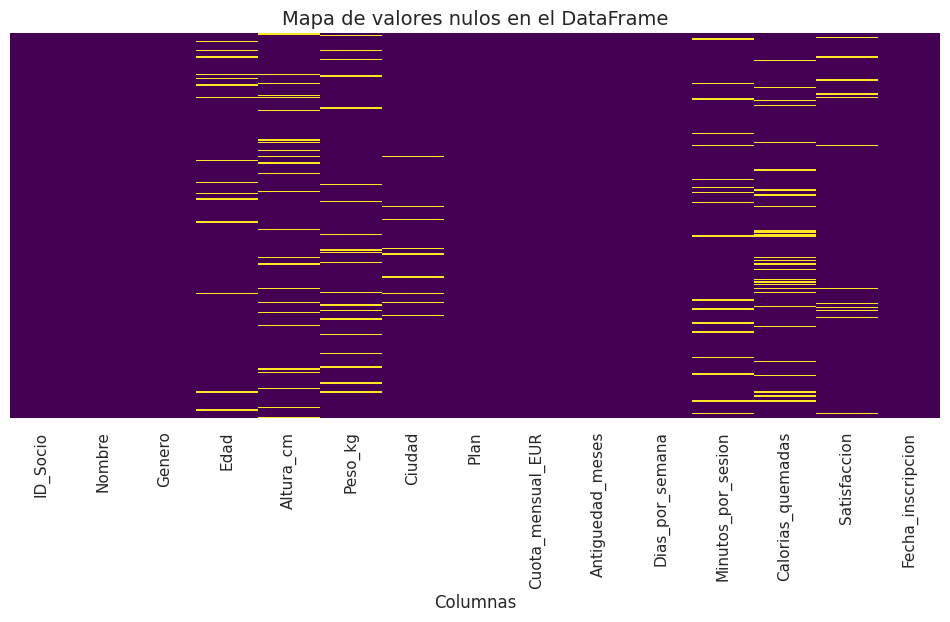

In [ ]:
plt.figure(figsize=(12, 5))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap="viridis")
plt.title("Mapa de valores nulos en el DataFrame", fontsize=14)
plt.xlabel("Columnas")
plt.show()

### ⚖️ ¿Qué hacemos con los nulos? Tres estrategias

#### 🔴 Opción A — **Eliminarlos** (`dropna()`)
Útil cuando hay **pocos** nulos o cuando una fila tiene la mayoría de valores en blanco.

#### 🟡 Opción B — **Imputarlos** (`fillna()`)
Sustituirlos por un valor estadístico:
*   **Media:** buena para distribuciones simétricas.
*   **Mediana:** mejor cuando hay outliers o sesgo.
*   **Moda:** para variables categóricas.

#### 🔵 Opción C — **Modelarlos**
Usar un algoritmo de machine learning para predecir el valor faltante (más avanzado).

> 🧠 **Regla de oro:** Elige una estrategia distinta para cada columna, según su naturaleza y el % de nulos.

In [ ]:
# Hacemos una copia "de seguridad" antes de limpiar, por si queremos comparar
df_original = df.copy()

print("Antes de imputar:")
print(df.isnull().sum().sort_values(ascending=False).head(10))

Antes de imputar:
Calorias_quemadas     30
Altura_cm             25
Peso_kg               21
Minutos_por_sesion    18
Edad                  15
Satisfaccion          12
Ciudad                 9
ID_Socio               0
Nombre                 0
Genero                 0
dtype: int64


In [ ]:
# --- Imputar 'Edad' con la MEDIANA (suele ser más robusta a outliers) ---
mediana_edad = df["Edad"].median()
df["Edad"] = df["Edad"].fillna(mediana_edad)
print(f"Edad → imputada con la mediana: {mediana_edad}")

# --- Imputar 'Altura_cm' y 'Peso_kg' con la MEDIA ---
media_altura = df["Altura_cm"].mean()
df["Altura_cm"] = df["Altura_cm"].fillna(media_altura)
print(f"Altura_cm → imputada con la media: {media_altura:.2f}")

media_peso = df["Peso_kg"].mean()
df["Peso_kg"] = df["Peso_kg"].fillna(media_peso)
print(f"Peso_kg → imputada con la media: {media_peso:.2f}")

# --- Imputar 'Minutos_por_sesion' y 'Calorias_quemadas' con la MEDIANA ---
df["Minutos_por_sesion"] = df["Minutos_por_sesion"].fillna(df["Minutos_por_sesion"].median())
df["Calorias_quemadas"]   = df["Calorias_quemadas"].fillna(df["Calorias_quemadas"].median())

# --- Imputar 'Satisfaccion' con la MODA (es una escala discreta 1-10) ---
moda_satisfaccion = df["Satisfaccion"].mode()[0]
df["Satisfaccion"] = df["Satisfaccion"].fillna(moda_satisfaccion)
print(f"Satisfaccion → imputada con la moda: {moda_satisfaccion}")

# --- Imputar 'Ciudad' (variable categórica) con la MODA ---
moda_ciudad = df["Ciudad"].mode()[0]
df["Ciudad"] = df["Ciudad"].fillna(moda_ciudad)
print(f"Ciudad → imputada con la moda: '{moda_ciudad}'")

Edad → imputada con la mediana: 36.0
Altura_cm → imputada con la media: 169.65
Peso_kg → imputada con la media: 76.80
Satisfaccion → imputada con la moda: 7.0
Ciudad → imputada con la moda: 'Madrid'


In [ ]:
# Verificamos que no queden nulos
print("Después de imputar:")
print(df.isnull().sum().sort_values(ascending=False))
print(f"\n✅ Total de NaN restantes: {df.isnull().sum().sum()}")

Después de imputar:
ID_Socio              0
Nombre                0
Genero                0
Edad                  0
Altura_cm             0
Peso_kg               0
Ciudad                0
Plan                  0
Cuota_mensual_EUR     0
Antiguedad_meses      0
Dias_por_semana       0
Minutos_por_sesion    0
Calorias_quemadas     0
Satisfaccion          0
Fecha_inscripcion     0
dtype: int64

✅ Total de NaN restantes: 0


---

## 9. 🚨 Detección y tratamiento de outliers (valores atípicos)

Un **outlier** es un valor que se aleja muchísimo del resto. Pueden ser:
*   🐛 **Errores** de entrada (ej: edad = 220).
*   🌟 **Casos reales pero raros** (ej: un atleta de élite que entrena 5 horas seguidas).

### 🔬 Dos métodos clásicos

#### A) **Método del Z-score**
Calcula cuántas desviaciones estándar se aleja un punto de la media. Si `|z| > 3` → outlier. Funciona bien en distribuciones normales.

#### B) **Método del IQR (Rango Intercuartílico)**
Basado en cuartiles (`Q1` y `Q3`). Los límites se fijan en `[Q1 - 1.5·IQR, Q3 + 1.5·IQR]`. Es **más robusto** ya que no asume normalidad.

### 📦 Visualizar outliers con boxplots

El **boxplot** (diagrama de caja) es la herramienta visual perfecta: los puntos que aparecen fuera de los "bigotes" son los outliers.

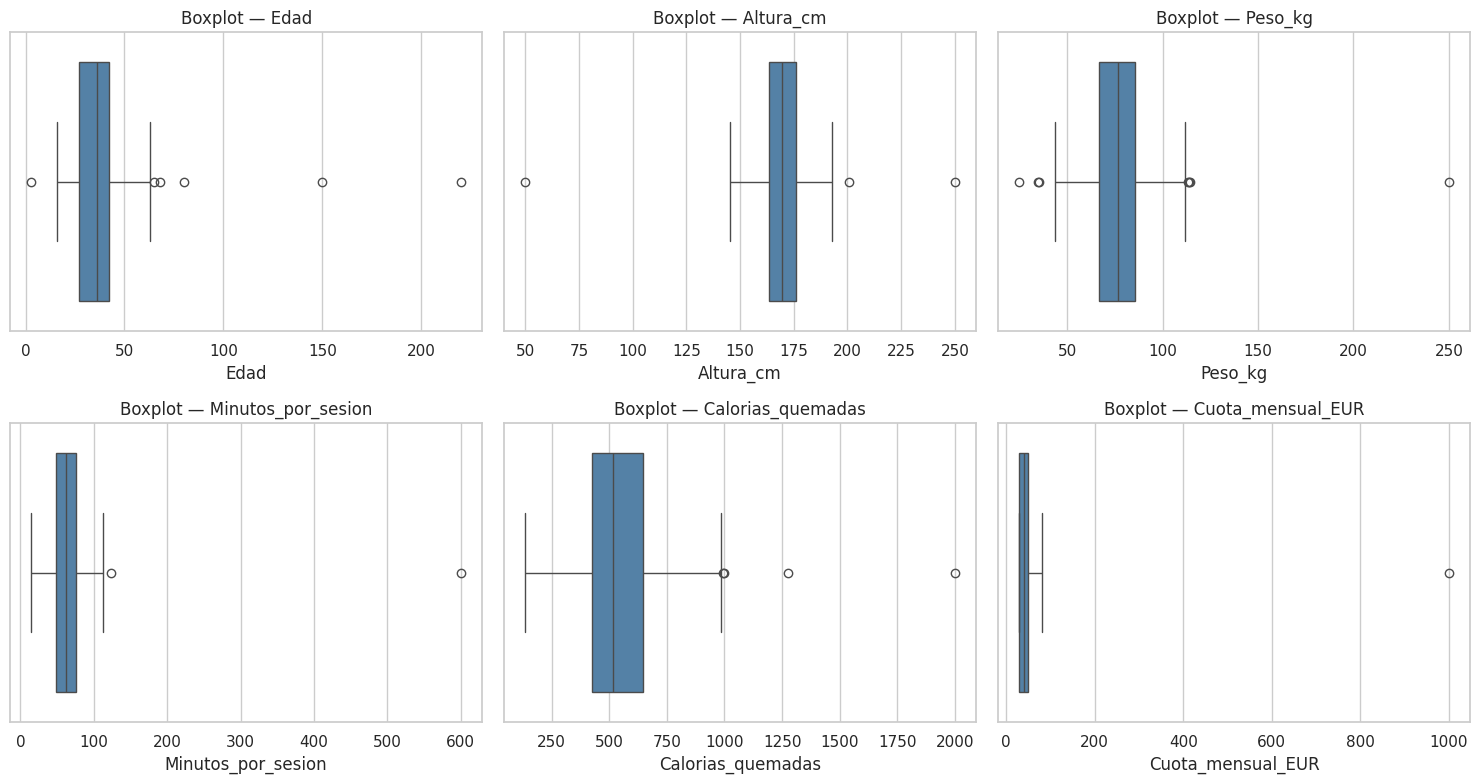

In [ ]:
# Boxplots de las variables numéricas más relevantes
columnas_num = ["Edad", "Altura_cm", "Peso_kg", "Minutos_por_sesion",
                "Calorias_quemadas", "Cuota_mensual_EUR"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), columnas_num):
    sns.boxplot(x=df[col], ax=ax, color="steelblue")
    ax.set_title(f"Boxplot — {col}")
plt.tight_layout()
plt.show()

¿Ves esos puntos que se separan mucho de la "caja"? Son los outliers que vamos a detectar y tratar.### 🅰️ Detectar outliers con el método del **Z-score**

In [ ]:
from scipy import stats

# Calculamos el Z-score de la columna 'Edad'
z_edad = np.abs(stats.zscore(df["Edad"]))

# Marcamos como outliers los valores con |z| > 3
outliers_edad = df[z_edad > 3]
print(f"🚨 Outliers detectados en 'Edad' usando Z-score (|z|>3): {len(outliers_edad)}")
outliers_edad[["ID_Socio", "Nombre", "Edad"]]

🚨 Outliers detectados en 'Edad' usando Z-score (|z|>3): 2


,ID_Socio,Nombre,Edad
5,1006,Claudia Rodríguez,150.0
120,1121,Miguel Serrano,220.0


### 🅱️ Detectar outliers con el método del **IQR**

In [ ]:
def detectar_outliers_iqr(serie):
    """Devuelve los límites inferior y superior según el método IQR."""
    Q1 = serie.quantile(0.25)
    Q3 = serie.quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    return limite_inferior, limite_superior

# Aplicamos el método a cada columna numérica
print(f"{'Columna':<25}{'Lím. inferior':>15}{'Lím. superior':>18}{'Nº outliers':>15}")
print("-" * 75)
for col in columnas_num:
    lim_inf, lim_sup = detectar_outliers_iqr(df[col])
    n_outliers = ((df[col] < lim_inf) | (df[col] > lim_sup)).sum()
    print(f"{col:<25}{lim_inf:>15.2f}{lim_sup:>18.2f}{n_outliers:>15}")

Columna                    Lím. inferior     Lím. superior    Nº outliers
---------------------------------------------------------------------------
Edad                                4.50             64.50              6
Altura_cm                         144.75            194.75              3
Peso_kg                            39.00            113.40              7
Minutos_por_sesion                 10.00            114.00              2
Calorias_quemadas                  88.00            984.00              4
Cuota_mensual_EUR                  -0.01             79.99              1


### 🛠️ Tratamiento de outliers

Tres opciones principales:
1. **Eliminar** las filas con outliers.
2. **Recortar (clipping):** limitar los valores extremos al límite del IQR.
3. **Imputar** con la mediana o un valor razonable.

In [ ]:
# Tratamos outliers SOLO en columnas donde son claramente errores
columnas_a_tratar = ["Edad", "Altura_cm", "Peso_kg", "Minutos_por_sesion"]

print("Antes de tratar outliers:")
print(df[columnas_a_tratar].describe().loc[["min", "max"]])

for col in columnas_a_tratar:
    lim_inf, lim_sup = detectar_outliers_iqr(df[col])
    mediana = df[col].median()
    # Sustituimos los valores fuera de los límites por la mediana
    df.loc[df[col] < lim_inf, col] = mediana
    df.loc[df[col] > lim_sup, col] = mediana

print("\nDespués de tratar outliers (sustituidos por la mediana):")
print(df[columnas_a_tratar].describe().loc[["min", "max"]])

Antes de tratar outliers:


      Edad  Altura_cm  Peso_kg  Minutos_por_sesion
min    3.0       50.0     25.0                15.0
max  220.0      250.0    250.0               600.0

Después de tratar outliers (sustituidos por la mediana):
     Edad  Altura_cm  Peso_kg  Minutos_por_sesion
min  16.0      145.3     43.8                15.0
max  63.0      192.7    111.8               112.0


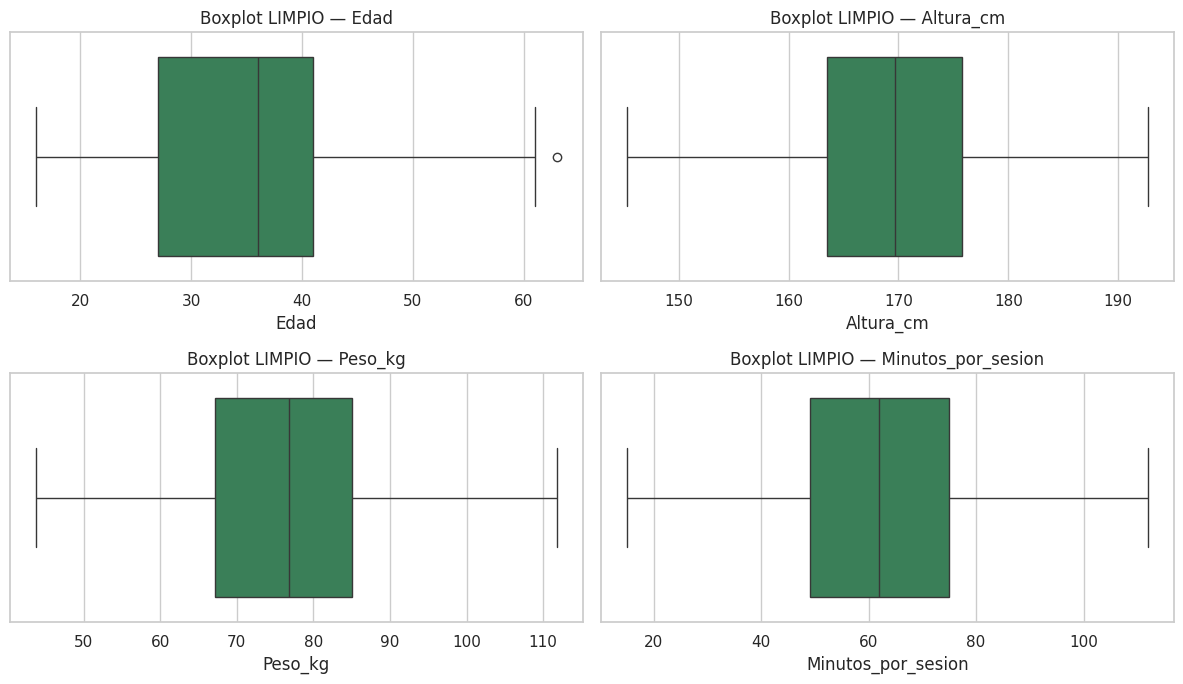

In [ ]:
# Visualizamos cómo han quedado los boxplots después de la limpieza
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for ax, col in zip(axes.ravel(), columnas_a_tratar):
    sns.boxplot(x=df[col], ax=ax, color="seagreen")
    ax.set_title(f"Boxplot LIMPIO — {col}")
plt.tight_layout()
plt.show()

---

## 10. 🎨 Análisis exploratorio visual (EDA)

Una vez los datos están limpios, podemos hacer **gráficos** para entenderlos mejor. Esto se llama **EDA** (Exploratory Data Analysis).

### 📊 Histogramas — distribución de cada variable
Un histograma nos muestra **cómo se reparten los valores** de una variable numérica.

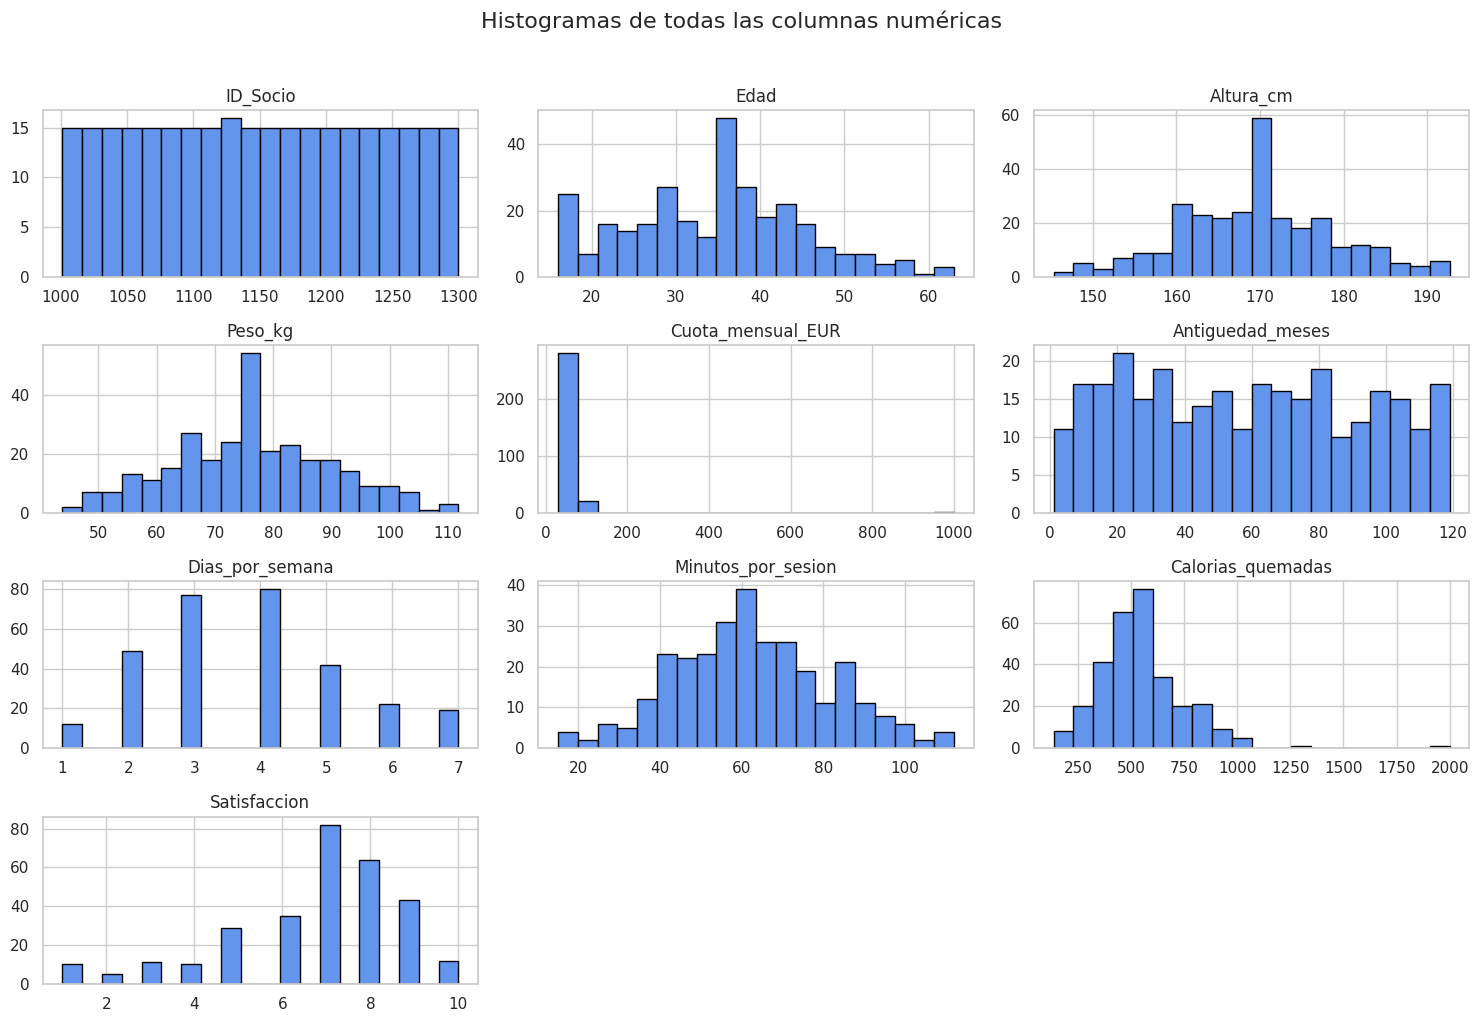

In [ ]:
df.hist(bins=20, figsize=(15, 10), color="cornflowerblue", edgecolor="black")
plt.suptitle("Histogramas de todas las columnas numéricas", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

### 📈 Distribuciones con `seaborn`

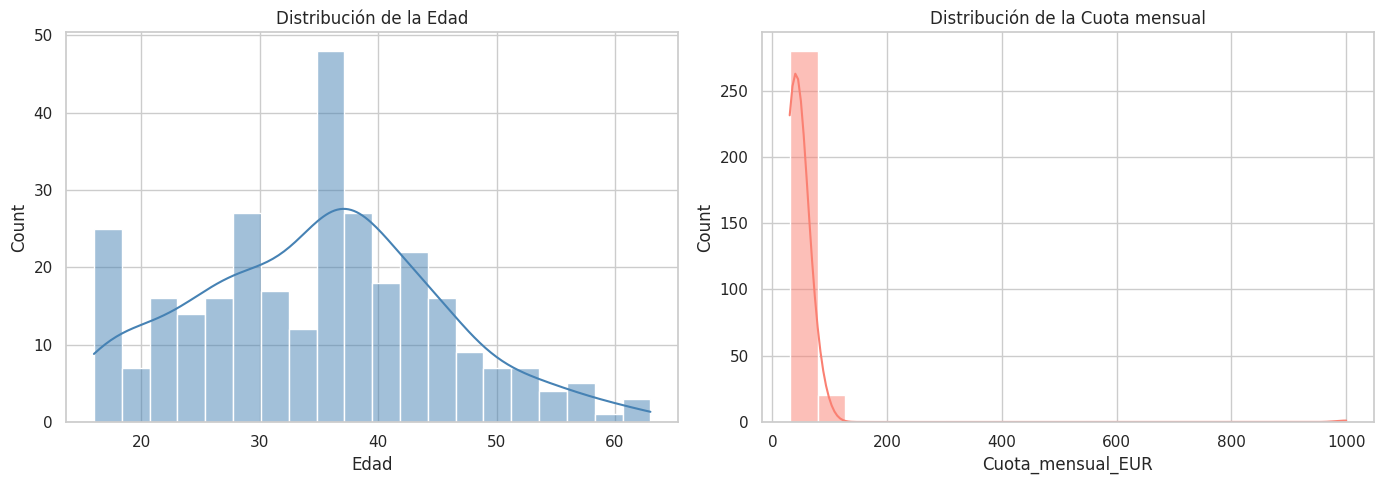

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["Edad"], kde=True, ax=axes[0], color="steelblue", bins=20)
axes[0].set_title("Distribución de la Edad")

sns.histplot(df["Cuota_mensual_EUR"], kde=True, ax=axes[1], color="salmon", bins=20)
axes[1].set_title("Distribución de la Cuota mensual")

plt.tight_layout()
plt.show()

### 🥧 Diagramas de barras / circulares para variables categóricas

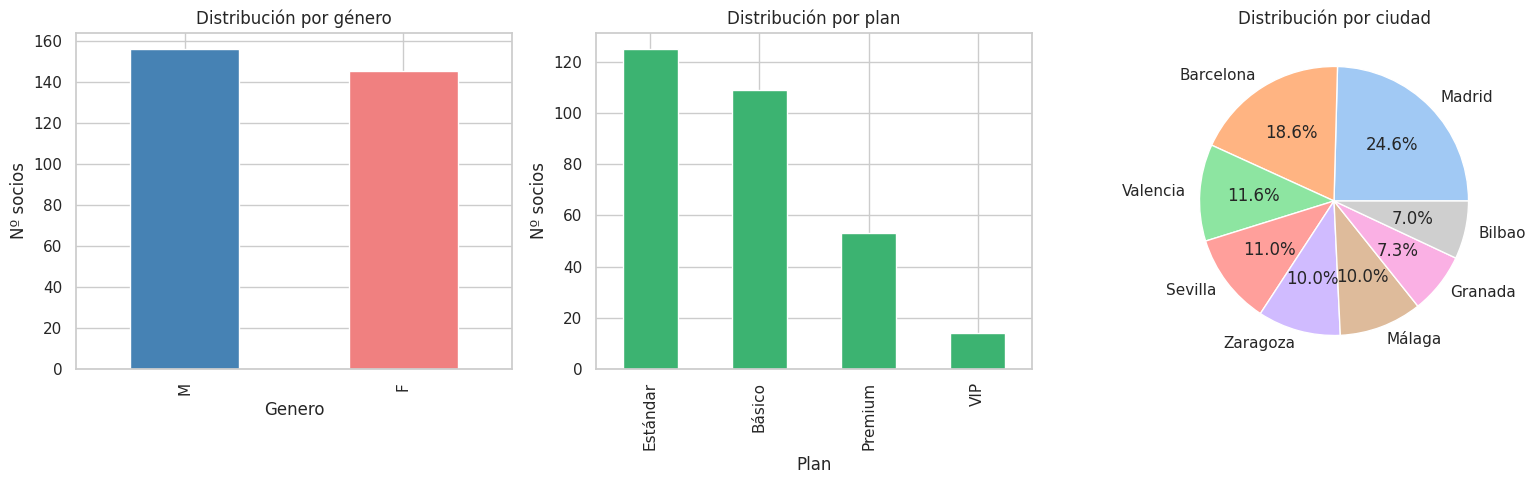

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

df["Genero"].value_counts().plot(kind="bar", ax=axes[0],
                                 color=["steelblue", "lightcoral"])
axes[0].set_title("Distribución por género")
axes[0].set_ylabel("Nº socios")

df["Plan"].value_counts().plot(kind="bar", ax=axes[1], color="mediumseagreen")
axes[1].set_title("Distribución por plan")
axes[1].set_ylabel("Nº socios")

df["Ciudad"].value_counts().plot(kind="pie", ax=axes[2], autopct='%1.1f%%')
axes[2].set_title("Distribución por ciudad")
axes[2].set_ylabel("")

plt.tight_layout()
plt.show()

### 🔥 Mapa de calor de correlaciones

La **correlación** mide la relación lineal entre dos variables numéricas. Va de **-1** (relación inversa) a **+1** (relación directa). **0** significa que no hay relación.

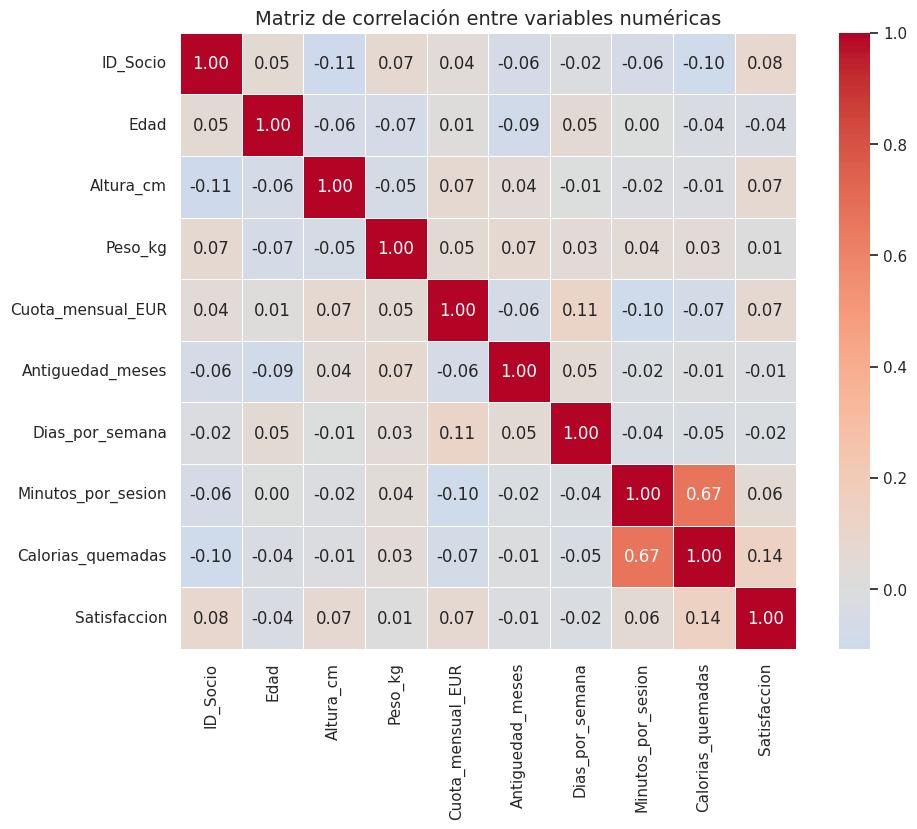

In [ ]:
# Solo columnas numéricas
columnas_numericas = df.select_dtypes(include=np.number).columns
matriz_corr = df[columnas_numericas].corr()

plt.figure(figsize=(11, 8))
sns.heatmap(matriz_corr, annot=True, fmt=".2f",
            cmap="coolwarm", center=0, square=True, linewidths=0.5)
plt.title("Matriz de correlación entre variables numéricas", fontsize=14)
plt.show()

### 🎯 Scatter plot — relaciones entre dos variables

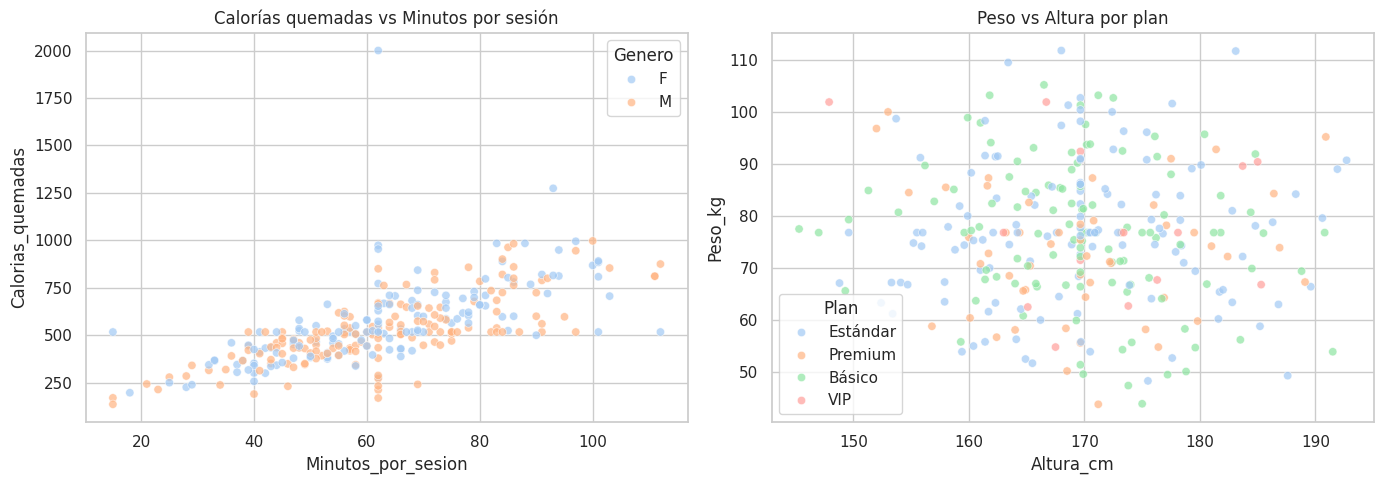

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=df, x="Minutos_por_sesion", y="Calorias_quemadas",
                hue="Genero", ax=axes[0], alpha=0.7)
axes[0].set_title("Calorías quemadas vs Minutos por sesión")

sns.scatterplot(data=df, x="Altura_cm", y="Peso_kg",
                hue="Plan", ax=axes[1], alpha=0.7)
axes[1].set_title("Peso vs Altura por plan")

plt.tight_layout()
plt.show()

---

## 11. 📐 Normalización y Estandarización

Cuando entrenamos modelos, las variables con escalas grandes pueden dominar el modelo. El escalado soluciona esto.

### 🆚 Normalización vs Estandarización

| Técnica | Resultado | ¿Cuándo usar? |
| :--- | :--- | :--- |
| **Normalización (Min-Max)** | Entre **0 y 1** | Redes neuronales, KNN, PCA |
| **Estandarización (Z-score)** | Media 0, std 1 | Regresión lineal, SVM, Logística |

> 🧠 **Idea clave:** La estandarización es la opción "por defecto" en la mayoría de modelos de scikit-learn.

In [ ]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Seleccionamos solo las columnas numéricas que queremos escalar
cols_a_escalar = ["Edad", "Altura_cm", "Peso_kg",
                  "Minutos_por_sesion", "Calorias_quemadas",
                  "Cuota_mensual_EUR", "Antiguedad_meses"]

# Hacemos copia para comparar
df_normalizado = df.copy()
df_estandarizado = df.copy()

In [ ]:
# --- 1) Normalización Min-Max → valores entre 0 y 1 ---
minmax = MinMaxScaler()
df_normalizado[cols_a_escalar] = minmax.fit_transform(df[cols_a_escalar])

print("📐 Después de NORMALIZAR (Min-Max):")
df_normalizado[cols_a_escalar].describe().round(3)

📐 Después de NORMALIZAR (Min-Max):


,Edad,Altura_cm,Peso_kg,Minutos_por_sesion,Calorias_quemadas,Cuota_mensual_EUR,Antiguedad_meses
count,301.000,301.000,301.000,301.000,301.000,301.000,301.000
mean,0.399,0.514,0.478,0.491,0.219,0.017,0.487
std,0.221,0.195,0.198,0.197,0.108,0.059,0.289
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,0.234,0.384,0.343,0.351,0.155,0.000,0.237
50%,0.426,0.514,0.485,0.485,0.204,0.010,0.475
75%,0.532,0.643,0.607,0.619,0.275,0.021,0.729
max,1.000,1.000,1.000,1.000,1.000,1.000,1.000


In [ ]:
# --- 2) Estandarización (Z-score) → media 0, std 1 ---
std = StandardScaler()
df_estandarizado[cols_a_escalar] = std.fit_transform(df[cols_a_escalar])

print("📐 Después de ESTANDARIZAR (Z-score):")
df_estandarizado[cols_a_escalar].describe().round(3)

📐 Después de ESTANDARIZAR (Z-score):


,Edad,Altura_cm,Peso_kg,Minutos_por_sesion,Calorias_quemadas,Cuota_mensual_EUR,Antiguedad_meses
count,301.000,301.000,301.000,301.000,301.000,301.000,301.000
mean,0.000,-0.000,-0.000,-0.000,-0.000,-0.000,-0.000
std,1.002,1.002,1.002,1.002,1.002,1.002,1.002
min,-1.807,-2.645,-2.414,-2.503,-2.038,-0.295,-1.691
25%,-0.748,-0.670,-0.684,-0.717,-0.601,-0.295,-0.867
50%,0.119,-0.003,0.037,-0.034,-0.137,-0.119,-0.044
75%,0.600,0.664,0.653,0.648,0.517,0.057,0.838
max,2.719,2.497,2.636,2.592,7.265,16.816,1.779


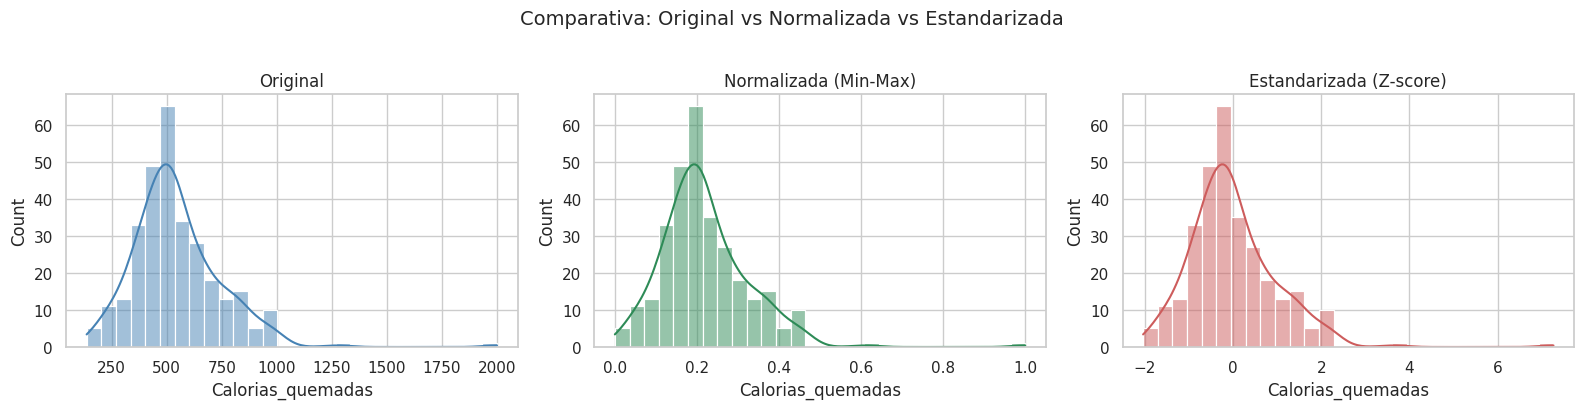

In [ ]:
# Comparamos visualmente las tres versiones de la columna 'Calorias_quemadas'
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.histplot(df["Calorias_quemadas"], kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Original")

sns.histplot(df_normalizado["Calorias_quemadas"], kde=True, ax=axes[1], color="seagreen")
axes[1].set_title("Normalizada (Min-Max)")

sns.histplot(df_estandarizado["Calorias_quemadas"], kde=True, ax=axes[2], color="indianred")
axes[2].set_title("Estandarizada (Z-score)")

plt.suptitle("Comparativa: Original vs Normalizada vs Estandarizada", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

> 👀 **Observación:** La **forma** de la distribución es la misma. Escalar **NO altera la información**, solo cambia la escala del eje X para facilitar el cálculo algorítmico.

---

## 12. 🚀 Pipeline completo de preprocesamiento

Vamos a recopilar **todos los pasos** anteriores en una única función reutilizable. Esto permite automatizar el proceso para nuevos datos de forma consistente.

In [ ]:
def preprocesar_dataset_gimnasio(ruta_csv: str) -> pd.DataFrame:
    """
    Pipeline completo de limpieza para el dataset del gimnasio GymPro.

    Pasos:
      1. Lectura del CSV.
      2. Eliminación de duplicados.
      3. Estandarización de columnas categóricas.
      4. Imputación de valores nulos.
      5. Tratamiento de outliers (IQR).
      6. Estandarización de columnas numéricas.
    """
    # 1) Leer
    df = pd.read_csv(ruta_csv)
    print(f"  [1] CSV leído. Forma inicial: {df.shape}")

    # 2) Duplicados
    n_dup = df.duplicated().sum()
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"  [2] Eliminados {n_dup} duplicados. Forma: {df.shape}")

    # 3) Limpieza de categóricas
    df["Genero"] = (df["Genero"].str.strip().str.lower()
                    .map({"m": "M", "f": "F",
                          "masculino": "M", "femenino": "F"}))
    df["Plan"]   = df["Plan"].str.strip().str.capitalize()
    df["Plan"]   = df["Plan"].replace({"Vip": "VIP"})
    df["Ciudad"] = df["Ciudad"].str.strip().str.capitalize()
    print("  [3] Categóricas estandarizadas.")

    # 4) Imputación de nulos
    for col in ["Edad", "Minutos_por_sesion", "Calorias_quemadas"]:
        df[col] = df[col].fillna(df[col].median())
    for col in ["Altura_cm", "Peso_kg"]:
        df[col] = df[col].fillna(df[col].mean())
    for col in ["Satisfaccion", "Ciudad"]:
        df[col] = df[col].fillna(df[col].mode()[0])
    print(f"  [4] Nulos imputados. NaN restantes: {df.isnull().sum().sum()}")

    # 5) Tratamiento de outliers (IQR)
    cols_outliers = ["Edad", "Altura_cm", "Peso_kg", "Minutos_por_sesion"]
    for col in cols_outliers:
        Q1, Q3 = df[col].quantile([0.25, 0.75])
        IQR = Q3 - Q1
        lim_inf, lim_sup = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
        mediana = df[col].median()
        df.loc[df[col] < lim_inf, col] = mediana
        df.loc[df[col] > lim_sup, col] = mediana
    print("  [5] Outliers tratados.")

    # 6) Estandarización (Z-score) de las numéricas
    cols_num = ["Edad", "Altura_cm", "Peso_kg",
                "Minutos_por_sesion", "Calorias_quemadas",
                "Cuota_mensual_EUR", "Antiguedad_meses"]
    scaler = StandardScaler()
    df[[c + "_z" for c in cols_num]] = scaler.fit_transform(df[cols_num])
    print("  [6] Columnas numéricas estandarizadas (sufijo _z).")

    return df

# Ejecutamos el pipeline
print("🚀 Ejecutando pipeline completo:\n")
df_limpio = preprocesar_dataset_gimnasio("gimnasio_gympro.csv")
print(f"\n✅ Pipeline finalizado. Forma final: {df_limpio.shape}")

🚀 Ejecutando pipeline completo:

  [1] CSV leído. Forma inicial: (308, 15)
  [2] Eliminados 7 duplicados. Forma: (301, 15)
  [3] Categóricas estandarizadas.
  [4] Nulos imputados. NaN restantes: 0
  [5] Outliers tratados.
  [6] Columnas numéricas estandarizadas (sufijo _z).

✅ Pipeline finalizado. Forma final: (301, 22)


In [ ]:
# Vista del DataFrame totalmente limpio y listo para modelar
df_limpio.head()

,ID_Socio,Nombre,Genero,Edad,Altura_cm,Peso_kg,Ciudad,Plan,Cuota_mensual_EUR,Antiguedad_meses,...,Calorias_quemadas,Satisfaccion,Fecha_inscripcion,Edad_z,Altura_cm_z,Peso_kg_z,Minutos_por_sesion_z,Calorias_quemadas_z,Cuota_mensual_EUR_z,Antiguedad_meses_z
0,1001,María Molina,F,41.0,169.653261,86.4000,Madrid,Estándar,29.99,103,...,465.0,7.0,2025-08-18,0.600452,-0.002941,0.749366,-0.612091,-0.396306,-0.295384,1.308893
1,1002,Daniel González,F,33.0,164.400000,76.8025,Granada,Premium,49.99,68,...,300.0,3.0,2024-07-18,-0.169867,-0.572803,0.036657,-1.084769,-1.219879,0.057436,0.279542
2,1003,Claudia López,F,43.0,177.500000,88.0000,Madrid,Básico,49.99,115,...,518.0,6.0,2021-04-25,0.793032,0.848256,0.868181,-0.296972,-0.131765,0.057436,1.661813
3,1004,Lucía García,F,53.0,176.100000,95.3000,Barcelona,Básico,39.99,1,...,949.0,7.0,2025-02-26,1.755930,0.696387,1.410278,1.646260,2.019506,-0.118974,-1.690930
4,1005,Daniel Navarro,M,32.0,169.800000,81.2000,Madrid,Básico,29.99,92,...,212.0,9.0,2020-07-04,-0.266157,0.012977,0.363215,-0.034373,-1.659117,-0.295384,0.985382


In [ ]:
# Lo guardamos como CSV listo para la siguiente fase (entrenamiento de modelos)
df_limpio.to_csv("gimnasio_gympro_LIMPIO.csv", index=False)
print("💾 Dataset limpio guardado como 'gimnasio_gympro_LIMPIO.csv'")

💾 Dataset limpio guardado como 'gimnasio_gympro_LIMPIO.csv'


---

## 🎓 Resumen final

Hemos recorrido el pipeline completo de preparación de datos:

| Fase | Herramientas / Métodos |
| :--- | :--- |
| **Preparación** | `import pandas`, `read_csv` |
| **Exploración** | `info()`, `describe()`, `heatmap` |
| **Limpieza** | `drop_duplicates`, `fillna`, `map` |
| **Outliers** | IQR, Z-score, Boxplots |
| **Transformación** | `MinMaxScaler`, `StandardScaler` |
| **Automatización** | Creación de un Pipeline (función) |

### 📚 Recursos Adicionales
*   [Documentación de Pandas](https://pandas.pydata.org/docs/)
*   [Documentación de Scikit-learn](https://scikit-learn.org/stable/)

---

### 🏆 Reto para casa
Coge **otro dataset cualquiera** (Kaggle, UCI) y aplica este mismo pipeline. **No hay dos datasets iguales**, pero el proceso es siempre similar.

> 💪 *"El 80% del tiempo en datos se dedica a la limpieza. Ahora ya sabes cómo hacerlo bien."*

---
**✏️ Profesor:** Miguel Ángel Navarro Arenas  
**🎓 UNIR — Estrategia del Dato: Machine Learning y Deep Learning**